# Análise Exploratória de Dados — Uber Ride Bookings 2024

Análise exploratória do dataset "Uber Ride Analytics Dashboard" (Kaggle), desenvolvida como atividade prática extra do curso Introdução à Inteligência Artificial (IP 20h A) — SENAI SC LAB365.

## 1. Setup e Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Opções de visualização do Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configurações de estilo para gráficos
sns.set_theme(style='whitegrid', palette='muted')

# Definição do caminho dos dados
DATA_PATH = '../data/ncr_ride_bookings.csv'

## 2. Carregamento e Inspeção Inicial

In [33]:
df = pd.read_csv(DATA_PATH)
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head(5)

Dimensões: 150000 linhas x 21 colunas


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90,14.00,NaN,NaN,NaN,NaN,1.00,Vehicle Breakdown,237.00,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.40,25.80,NaN,NaN,NaN,NaN,NaN,NaN,627.00,13.58,4.90,4.90,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.10,28.50,NaN,NaN,NaN,NaN,NaN,NaN,416.00,34.02,4.60,5.00,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.30,19.60,NaN,NaN,NaN,NaN,NaN,NaN,737.00,48.21,4.10,4.30,UPI


In [34]:
# Verificação dos tipos de dados e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [35]:
# Análise de valores nulos por coluna
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'percentual_%': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos[nulos['nulos'] > 0].sort_values('percentual_%', ascending=False)

,nulos,percentual_%
Incomplete Rides,141000,94.00
Incomplete Rides Reason,141000,94.00
Cancelled Rides by Customer,139500,93.00
Reason for cancelling by Customer,139500,93.00
Cancelled Rides by Driver,123000,82.00
Driver Cancellation Reason,123000,82.00
Driver Ratings,57000,38.00
Customer Rating,57000,38.00
Avg CTAT,48000,32.00
Ride Distance,48000,32.00


In [36]:
# Verificação de registros duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [37]:
# Verificação da estatística descritiva das variáveis numéricas   
cols_numericas = ['Avg VTAT',
                  'Avg CTAT',
                  'Cancelled Rides by Customer', 
                  'Cancelled Rides by Driver',
                  'Incomplete Rides',
                  'Booking Value', 
                  'Ride Distance',
                  'Driver Ratings',
                  'Customer Rating'
                ]

df[cols_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Avg VTAT,139500.00,8.46,3.77,2.00,5.30,8.30,11.30,20.00
Avg CTAT,102000.00,29.15,8.90,10.00,21.60,28.80,36.80,45.00
Cancelled Rides by Customer,10500.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Cancelled Rides by Driver,27000.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Incomplete Rides,9000.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Booking Value,102000.00,508.30,395.81,50.00,234.00,414.00,689.00,4277.00
Ride Distance,102000.00,24.64,14.00,1.00,12.46,23.72,36.82,50.00
Driver Ratings,93000.00,4.23,0.44,3.00,4.10,4.30,4.60,5.00
Customer Rating,93000.00,4.40,0.44,3.00,4.20,4.50,4.80,5.00


In [38]:
# Contagem da frequência das variáveis categóricas
df.describe(include='object').T

,count,unique,top,freq
Date,150000,365,2024-11-16,462
Time,150000,62910,17:44:57,16
Booking ID,150000,148767,"""CNR3648267""",3
Booking Status,150000,5,Completed,93000
Customer ID,150000,148788,"""CID6715450""",3
Vehicle Type,150000,7,Auto,37419
Pickup Location,150000,176,Khandsa,949
Drop Location,150000,176,Ashram,936
Reason for cancelling by Customer,10500,5,Wrong Address,2362
Driver Cancellation Reason,27000,4,Customer related issue,6837


### Observações Iniciais

1. **Volume e Período**: O dataset compreende 150.000 registros de corridas referentes ao ano de 2024.
2. **Tipos de Dados**: As colunas `Date` e `Time` foram identificadas como tipo `object` (strings), exigindo conversão para formatos de data/hora adequados para análise temporal.
3. **Valores Ausentes**: Existe uma natureza estrutural nos nulos; colunas como `Reason for cancelling by Customer` possuem valores apenas quando `Booking Status` é 'Cancelled by Customer', portanto, os nulos são esperados e não indicam falha na coleta.
4. **Duplicatas**: Não foram encontrados registros duplicados, o que garante a integridade e unicidade de cada transação de reserva no conjunto de dados.

## 3. Limpeza e Preparação dos Dados

In [39]:
# Verificação de registros duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [40]:
# Padronização dos nomes de colunas para snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Remoção de aspas extras em booking_id e customer_id
df['booking_id'] = df['booking_id'].str.replace('"', '').str.strip()
df['customer_id'] = df['customer_id'].str.replace('"', '').str.strip()

#Verificação da exclusão das aspas extras em booking_id e customer_id
cols = ['booking_id', 'customer_id']
df[cols].head(5)

,booking_id,customer_id
0,CNR5884300,CID1982111
1,CNR1326809,CID4604802
2,CNR8494506,CID9202816
3,CNR8906825,CID2610914
4,CNR1950162,CID9933542


## Engenharia de Feature

In [41]:
# Conversão de Date e Time para datetime único
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])

# Conversão da coluna date para datetime
df['date'] = pd.to_datetime(df['date'])

print("Tipos após conversão:")
print(df[['date', 'time', 'datetime']].dtypes)
df[['date', 'time', 'datetime']].head(5)

Tipos após conversão:
date        datetime64[ns]
time                object
datetime    datetime64[ns]
dtype: object


,date,time,datetime
0,2024-03-23,12:29:38,2024-03-23 12:29:38
1,2024-11-29,18:01:39,2024-11-29 18:01:39
2,2024-08-23,08:56:10,2024-08-23 08:56:10
3,2024-10-21,17:17:25,2024-10-21 17:17:25
4,2024-09-16,22:08:00,2024-09-16 22:08:00


In [42]:
# Feature Engineering de variáveis temporais
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['month_num'] = df['datetime'].dt.month
df['month_name'] = df['datetime'].dt.strftime('%B')
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Categorização do período do dia
df['period_of_day'] = pd.cut(
    df['hour'], 
    bins=[-1, 5, 11, 17, 23], 
    labels=['Madrugada', 'Manhã', 'Tarde', 'Noite']
)

# Flags adicionais e métricas de avaliação
df['is_completed'] = df['booking_status'] == 'Completed'
df['rating_diff'] = df['customer_rating'] - df['driver_ratings']

In [43]:
# Verificação das novas features criadas
cols_features = ['datetime', 'hour', 'day_of_week', 'month_name', 
                 'is_weekend', 'period_of_day', 'is_completed', 'rating_diff']
df[cols_features].head(10)

,datetime,hour,day_of_week,month_name,is_weekend,period_of_day,is_completed,rating_diff
0,2024-03-23 12:29:38,12,Saturday,March,True,Tarde,False,NaN
1,2024-11-29 18:01:39,18,Friday,November,False,Noite,False,NaN
2,2024-08-23 08:56:10,8,Friday,August,False,Manhã,True,0.00
3,2024-10-21 17:17:25,17,Monday,October,False,Tarde,True,0.40
4,2024-09-16 22:08:00,22,Monday,September,False,Noite,True,0.20
5,2024-02-06 09:44:56,9,Tuesday,February,False,Manhã,True,0.50
6,2024-06-17 15:45:58,15,Monday,June,False,Tarde,True,0.10
7,2024-03-19 17:37:37,17,Tuesday,March,False,Tarde,True,-0.20
8,2024-09-14 12:49:09,12,Saturday,September,True,Tarde,False,NaN
9,2024-12-16 19:06:48,19,Monday,December,False,Noite,False,NaN


### Observações

A criação das features temporais visa enriquecer o dataframe com dimensões analíticas derivadas das colunas de data e hora originais. Variáveis como `hour`, `day_of_week` e `period_of_day` permitirão identificar padrões cíclicos de demanda nas seções seguintes. As flags `is_completed` e `rating_diff` foram criadas para facilitar análises segmentadas por desfecho da corrida.

## 5. Análise Univariada — Variáveis Categóricas

In [44]:
# Distribuição absoluta e percentual das principais variáveis categóricas
for col in ['booking_status', 'vehicle_type', 'payment_method']:
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(2)
    print(pd.DataFrame({'contagem': counts, 'percentual_%': pct}).to_string())
    print()

                       contagem  percentual_%
booking_status                               
Completed                 93000         62.00
Cancelled by Driver       27000         18.00
No Driver Found           10500          7.00
Cancelled by Customer     10500          7.00
Incomplete                 9000          6.00

               contagem  percentual_%
vehicle_type                         
Auto              37419         24.95
Go Mini           29806         19.87
Go Sedan          27141         18.09
Bike              22517         15.01
Premier Sedan     18111         12.07
eBike             10557          7.04
Uber XL            4449          2.97

                contagem  percentual_%
payment_method                        
UPI                45909         45.01
Cash               25367         24.87
Uber Wallet        12276         12.04
Credit Card        10209         10.01
Debit Card          8239          8.08



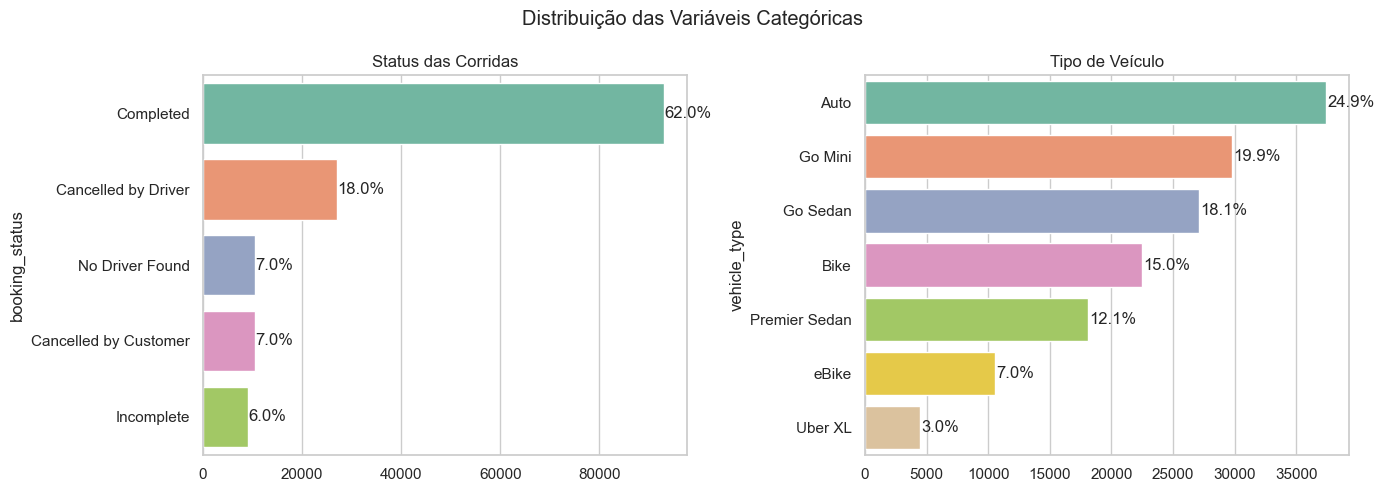

In [46]:
# Visualização do Status das Corridas e Tipo de Veículo
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Status das Corridas
status_counts = df['booking_status'].value_counts()
status_pct = df['booking_status'].value_counts(normalize=True).mul(100)
sns.barplot(x=status_counts.values, y=status_counts.index, ax=ax[0], palette='Set2')
ax[0].set_title("Status das Corridas")

# Anotações de percentual
for i, v in enumerate(status_counts.values):
    pct = status_pct.iloc[i]
    ax[0].text(v + 100, i, f'{pct:.1f}%', va='center')

# Subplot 2: Tipo de Veículo
vehicle_counts = df['vehicle_type'].value_counts()
vehicle_pct = df['vehicle_type'].value_counts(normalize=True).mul(100)
sns.barplot(x=vehicle_counts.values, y=vehicle_counts.index, ax=ax[1], palette='Set2')
ax[1].set_title("Tipo de Veículo")

# Anotações de percentual
for i, v in enumerate(vehicle_counts.values):
    pct = vehicle_pct.iloc[i]
    ax[1].text(v + 100, i, f'{pct:.1f}%', va='center')

plt.suptitle("Distribuição das Variáveis Categóricas")
plt.tight_layout()
plt.show()

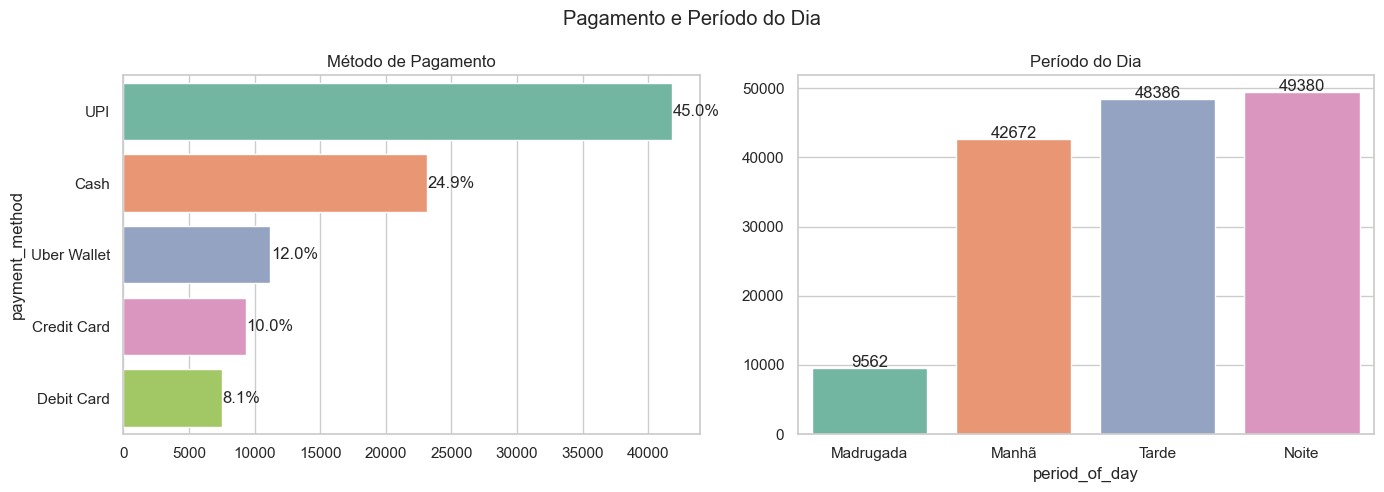

In [47]:
# Visualização do Método de Pagamento e Período do Dia
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Método de Pagamento (Apenas Corridas Completadas)
df_comp = df[df['booking_status'] == 'Completed']
pay_counts = df_comp['payment_method'].value_counts()
pay_pct = df_comp['payment_method'].value_counts(normalize=True).mul(100)
sns.barplot(x=pay_counts.values, y=pay_counts.index, ax=ax[0], palette='Set2')
ax[0].set_title("Método de Pagamento")

# Anotações
for i, v in enumerate(pay_counts.values):
    pct = pay_pct.iloc[i]
    ax[0].text(v + 50, i, f'{pct:.1f}%', va='center')

# Subplot 2: Período do Dia (Ordenado Cronologicamente)
period_order = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
period_counts = df['period_of_day'].value_counts().reindex(period_order)
sns.barplot(x=period_counts.index, y=period_counts.values,
            ax=ax[1], order=period_order, palette='Set2')
ax[1].set_title("Período do Dia")

# Anotações de contagem no topo
for i, v in enumerate(period_counts.values):
    ax[1].text(i, v + 200, str(int(v)), ha='center')

plt.suptitle("Pagamento e Período do Dia")
plt.tight_layout()
plt.show()

### Análise sobre as variáveis categóricas

1. **booking_status**: Aproximadamente 62% das corridas são completadas com sucesso. O volume combinado de cancelamentos pelo cliente, pelo motorista e registros sem motorista disponível (No Driver Found) representa um desafio operacional relevante na conversão das solicitações.
2. **vehicle_type**: O Auto é o tipo de veículo mais utilizado (24,9%), possivelmente pela maior disponibilidade e custo-benefício para o perfil médio de usuário. O Uber XL apresenta a menor frequência (3,0%), o que pode ser reflexo de uma menor disponibilidade de motoristas ou menor demanda por veículos de maior capacidade.
3. **payment_method**: Existe uma clara dominância dos pagamentos via UPI, indicando um perfil de usuário altamente digitalizado que prefere métodos de transação instantânea.
4. **period_of_day**: O período da Noite concentra o maior volume absoluto de solicitações (49.380 registros), consolidando-se como o pico real de demanda. Este padrão sugere forte influência dos horários de saída comercial e fluxos de lazer no volume de corridas.

## 6. Análise Univariada — Variáveis Numéricas

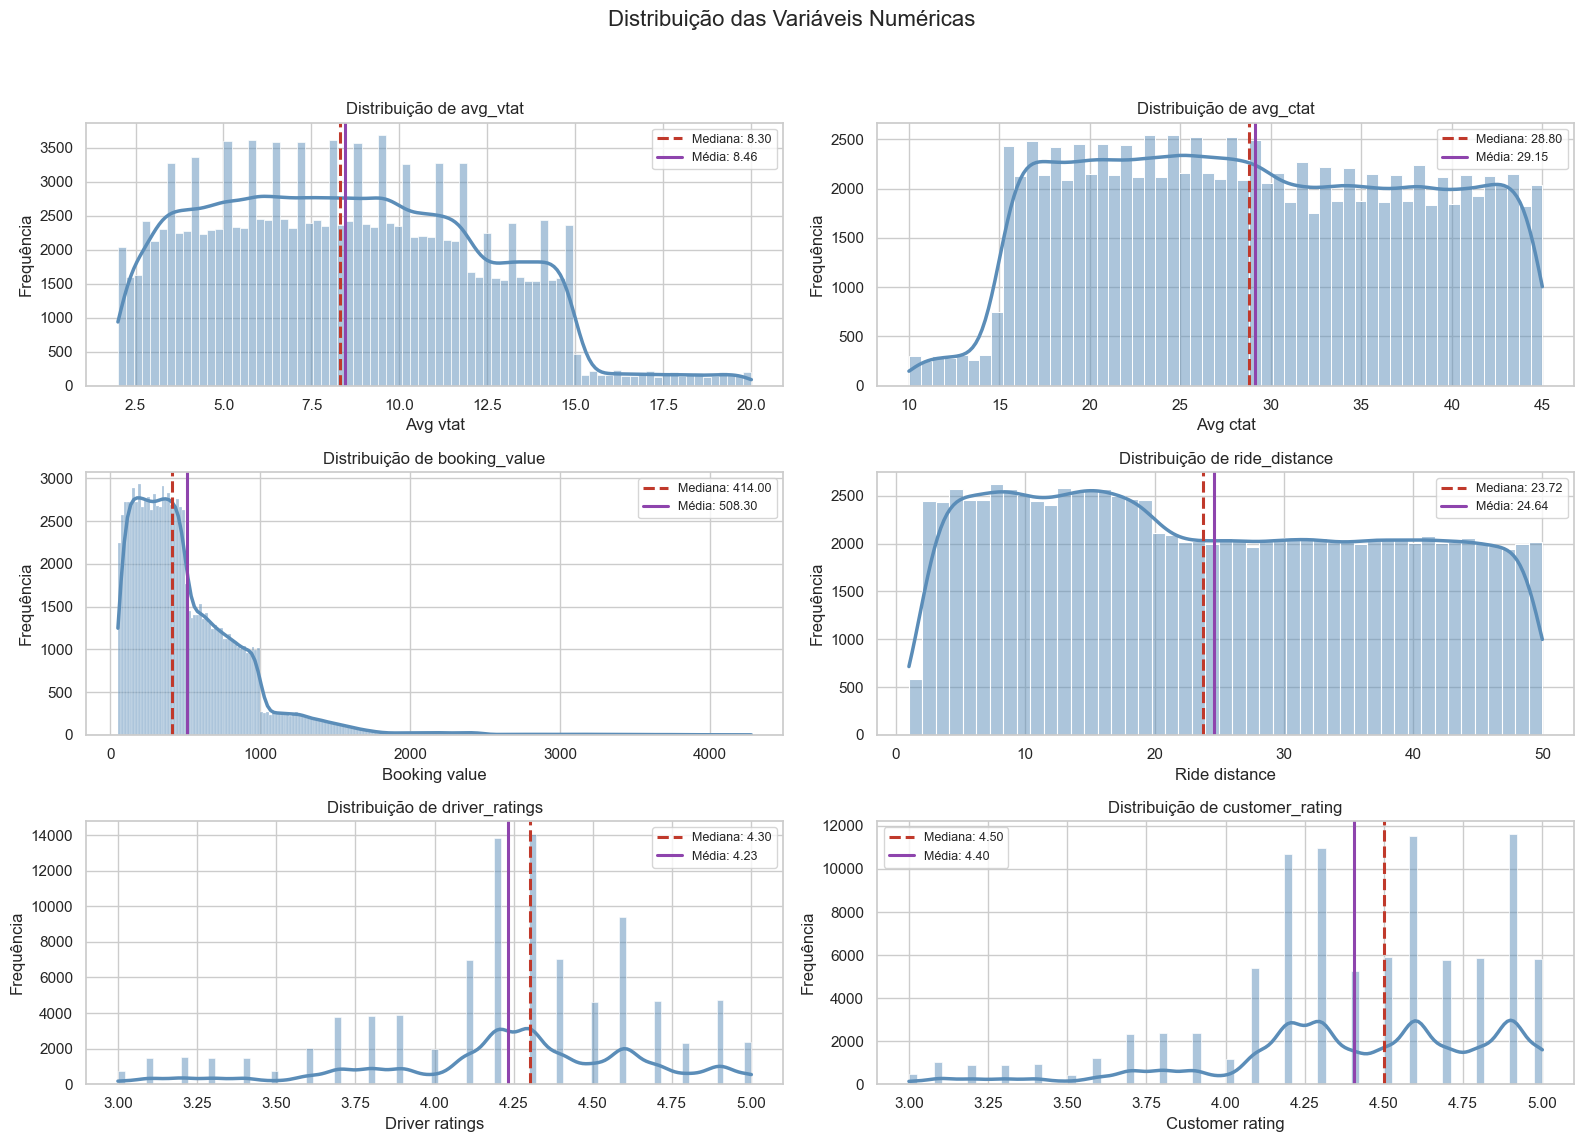

In [64]:
# Distribuição das Variáveis Numéricas com Histogramas e KDE
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

cols_numericas = ['avg_vtat', 'avg_ctat', 'booking_value',
                  'ride_distance', 'driver_ratings', 'customer_rating']

for i, col in enumerate(cols_numericas):
    mediana = df[col].median()
    media = df[col].mean()

    sns.histplot(df[col], kde=True, ax=axes[i],
                 color='#5b8db8', alpha=0.5,
                 line_kws={'linewidth': 2.5})
    axes[i].axvline(mediana, color='#c0392b', linestyle='--', linewidth=2.2,
                label=f'Mediana: {mediana:.2f}')  # vermelho escuro
    axes[i].axvline(media, color='#8e44ad', linestyle='-', linewidth=2.2,
                label=f'Média: {media:.2f}')  # roxo

    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col.replace('_', ' ').capitalize())
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)

plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análise sobre as variáveis numéricas

1. **avg_vtat e avg_ctat**: O avg_vtat apresenta mediana de aproximadamente 8 minutos, enquanto o avg_ctat tem mediana de aproximadamente 29 minutos. A diferença expressiva entre as duas métricas sugere que o tempo de espera total da corrida é dominado pelo CTAT. Essa assimetria levanta a hipótese de que tempos elevados de CTAT possam estar associados a cancelamentos pelo cliente — relação a ser investigada na análise de cancelamentos.
2. **booking_value**: Apresenta alta variabilidade e distribuição assimétrica à direita. A maioria das corridas concentra-se em valores mais baixos, mas a presença de viagens de maior distância puxa a média acima da mediana, evidenciada pelo coeficiente de variação elevado.
3. **ride_distance**: A distribuição está espalhada entre 1 e 50 km, com mediana próxima a 24 km, indicando que a plataforma atende tanto trajetos curtos quanto deslocamentos de maior distância de forma relativamente equilibrada.
4. **driver_ratings e customer_rating**: Ambas as métricas estão concentradas entre 4.0 e 5.0. A avaliação média atribuída pelos clientes (4.40) é ligeiramente superior à média recebida pelos motoristas (4.23), diferença a ser explorada na análises de satisfação em seções seguintes.